In [26]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import coint

# o cwd do notebook é notebooks/, então todo caminho precisa sair da raiz do projeto
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = RAIZ / "data"
sys.path.insert(0, str(RAIZ / "src"))

from moq import metrics

plt.rcParams["figure.figsize"] = (10, 4)

R = pd.read_parquet( DATA / "processed" / "retornos_oos.parquet")
cdi = pd.read_parquet( DATA / "processed" / "cdi.parquet")["cdi"].reindex(R.index)
F = pd.read_parquet( DATA / "processed" / "fatores.parquet").reindex(R.index)
print(R.shape, R.index.min().date(), "->", R.index.max().date())
R.head()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
(2912, 4) 2015-01-02 -> 2026-09-14


,momentum,reversao,pares,carry
Date,,,,
2015-01-02,-0.001000,0.000435,0.000435,0.000694
2015-01-05,-0.011315,0.000435,0.000435,0.000959
2015-01-06,0.018740,0.000435,0.000435,0.001046
2015-01-07,0.028662,0.000435,0.000435,0.001309
2015-01-08,0.010103,0.022220,0.000435,0.000775


In [27]:
tabela = pd.DataFrame({c: metrics.summary(R[c], cdi) for c in R.columns}).T
tabela["turnover"] = np.nan
corr = R.corr()
tabela["corr_media"] = (corr.sum(axis=1) - 1) / (len(corr) - 1)
tabela.sort_values("sharpe", ascending=False).round(3)

,ret_anual,vol_anual,sharpe,max_dd,turnover,corr_media
momentum,0.166,0.266,0.354,-0.541,NaN,0.027
carry,0.099,0.010,-0.080,-0.025,NaN,0.023
pares,0.037,0.089,-0.616,-0.176,NaN,-0.031
reversao,-0.213,0.343,-0.790,-0.954,NaN,0.050


Quem tem o melhor Sharpe é a estratégia de reversão, quem tem o pior drawndown é a estratégia de carry, e quem tem a menor correlação média é a estratégia de pares.

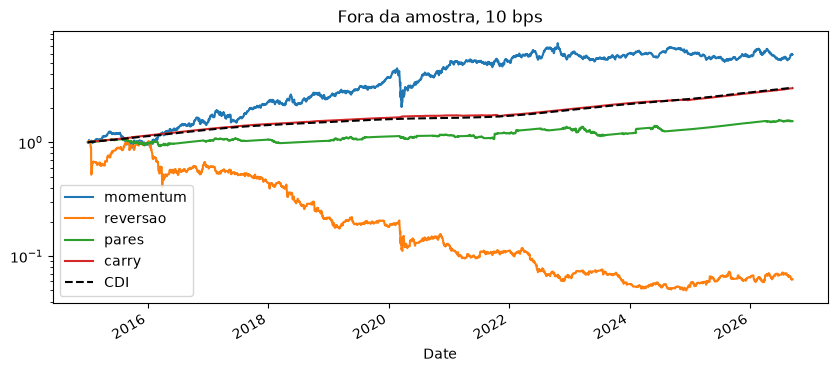

In [28]:
(1 + R).cumprod().plot(logy=True, title="Fora da amostra, 10 bps")
(1 + cdi).cumprod().plot(logy= True, color="black", ls="--", label="CDI"); plt.legend();

In [29]:
ativo = (R["pares"] - cdi).abs() > 1e-10
print("correlação pares x momentum, todos os dias: ", R["pares"].corr(R["momentum"]).round(2))
print("correlação pares x momentum, só dois dias ativos: ", R.loc[ativo, "pares"].corr(R.loc[ativo, "momentum"]).round(2))

correlação pares x momentum, todos os dias:  -0.1
correlação pares x momentum, só dois dias ativos:  -0.13


In [30]:
pior5 = F["MKT"] <= F["MKT"].quantile(0.05)
print("dias de estresse:", pior5.sum())
R[pior5].corr().round(2)

dias de estresse: 143


,momentum,reversao,pares,carry
momentum,1.00,0.60,0.10,-0.04
reversao,0.60,1.00,0.05,-0.11
pares,0.10,0.05,1.00,0.12
carry,-0.04,-0.11,0.12,1.00


Em geral, em dias de estresse a correlção entre as estratégias é próximo de zero, isso significa que a diversificação sobrevive à esses períodos, haja vista que o desempenho de uma não é afetado pelo desempenho da outra.

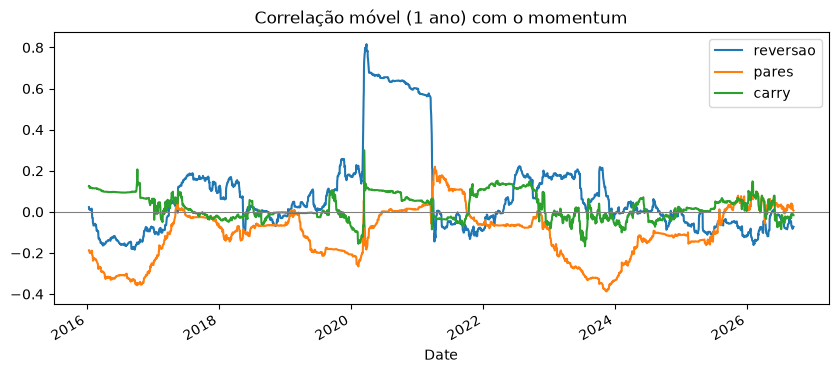

In [31]:
R.drop(columns="momentum").rolling(252).corr(R["momentum"]).plot(title="Correlação móvel (1 ano) com o momentum")
plt.axhline(0, color="gray", lw=0.8);

In [32]:
from moq import portfolio

w_ew = portfolio.equal_weight(R)
p_ew = portfolio.combine(R, w_ew)
print("Sharpe pesos iguais:", round(metrics.sharpe(p_ew, cdi), 2))
print("Melhor isolada:      ", round(tabela["sharpe"].max(), 2))

Sharpe pesos iguais: -0.5
Melhor isolada:       0.35


In [33]:
vols = R.std(ddof=1) * np.sqrt(252)
vols.round(3)

momentum    0.266
reversao    0.343
pares       0.089
carry       0.010
dtype: float64

In [34]:
cov = R.cov() * 252
rc_ew = w_ew * (cov @ w_ew)                 # contribuição de cada uma para a variância
(rc_ew / rc_ew.sum()).round(2)              # fração do risco total

momentum    0.38
reversao    0.60
pares       0.02
carry       0.00
dtype: float64

In [35]:
inv = 1 / vols
w_rp = inv / inv.sum()
w_rp.round(3)
rc_rp = w_rp * (cov @ w_rp)
(rc_rp / rc_rp.sum()).round(2)              # agora deve ficar mais equilibrado

momentum    0.26
reversao    0.27
pares       0.22
carry       0.25
dtype: float64

In [36]:
from scipy.optimize import minimize

ex = R.sub(cdi, axis=0)
mu = ex.mean().to_numpy() * 252
cov_np = ex.cov().to_numpy() * 252
n = len(mu)

def neg_sharpe(w):
    var = w @ cov_np @ w
    return 0.0 if var <= 0 else -(w @ mu) / np.sqrt(var)

res = minimize(neg_sharpe, np.full(n, 1 / n), method="SLSQP",
               bounds=[(0, 1)] * n, constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1}])
pd.Series(res.x, index=R.columns).round(3)

momentum    1.0
reversao    0.0
pares       0.0
carry       0.0
dtype: float64

In [37]:
def max_sharpe_weights(ex, w_max=0.4, shrink=0.5):
    mu = ex.mean().to_numpy() * 252
    mu = (1 - shrink) * mu + shrink * mu.mean()          # puxa todas as médias para a média comum
    cov = ex.cov().to_numpy() * 252
    n = len(mu)
    def neg_sharpe(w):
        var = w @ cov @ w
        return 0.0 if var <= 0 else -(w @ mu) / np.sqrt(var)
    res = minimize(neg_sharpe, np.full(n, 1 / n), method="SLSQP",
                   bounds=[(0, w_max)] * n, constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1}])
    return pd.Series(res.x, index=ex.columns)

for shrink in (0.0, 0.5, 1.0):
    print(f"shrink={shrink}:", max_sharpe_weights(ex, w_max=0.4, shrink=shrink).round(2).to_dict())

shrink=0.0: {'momentum': 0.4, 'reversao': 0.0, 'pares': 0.2, 'carry': 0.4}
shrink=0.5: {'momentum': 0.4, 'reversao': 0.0, 'pares': 0.2, 'carry': 0.4}
shrink=1.0: {'momentum': 0.4, 'reversao': 0.4, 'pares': 0.0, 'carry': 0.2}


Pesos que mudam muito com uma escolha de parâmetro que você não tem como calibrar são pesos em que não se pode confiar

In [38]:
alocacoes = {
    "pesos_iguais": portfolio.equal_weight(R),
    "risk_parity": portfolio.risk_parity(R),
    "max_sharpe": portfolio.max_sharpe(R, cdi, w_max=0.4, shrink=0.5)
}

pd.DataFrame(alocacoes).round(3)

P = pd.DataFrame({nome: portfolio.combine(R, w) for nome, w in alocacoes.items()})
comparacao = pd.DataFrame({c: metrics.summary(P[c], cdi) for c in P.columns}).T
comparacao.loc["melhor_isolada"] = tabela.loc[tabela["sharpe"].idxmax(), comparacao.columns]
comparacao.round(3)

,ret_anual,vol_anual,sharpe,max_dd
pesos_iguais,0.031,0.117,-0.497,-0.267
risk_parity,0.089,0.018,-0.554,-0.028
max_sharpe,0.123,0.106,0.248,-0.249
melhor_isolada,0.166,0.266,0.354,-0.541


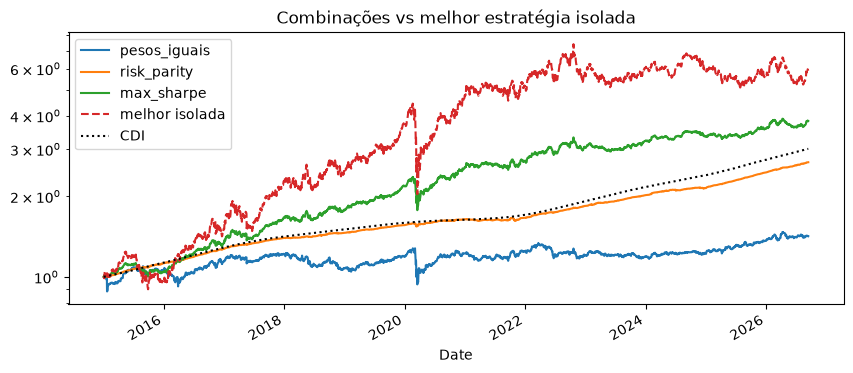

In [39]:
ax = (1 + P).cumprod().plot(logy=True, title="Combinações vs melhor estratégia isolada")
(1 + R[tabela["sharpe"].idxmax()]).cumprod().plot(ax=ax, ls="--", label="melhor isolada")
(1 + cdi).cumprod().plot(ax=ax, color="black", ls=":", label="CDI"); ax.legend();

Nenhuma das três combinações bateu a melhor isolada: o momentum sozinho fez Sharpe 0.35 e a melhor combinação, o max_sharpe, fez 0.25 - um terço a menos. Entre os métodos, o max_sharpe ganhou por muito (0.25 contra -0.50 dos pesos iguais e -0.55 do risk parity), e a razão é simples: ele foi o único que pôde zerar a reversão, a estratégia que perdeu 21% ao ano e arrastou as outras duas alocações para baixo do CDI. 

O que a combinação comprou não foi retorno, e sim risco: o drawndown máximo caiu de -54% (momentum sozinho) para -25% no max_sharpe e -3% no risk parity, com a vol anual saindo de 27% para 11% e 2% - se o critério fosse "quanto de perda eu aguento", a conclusão se inverteria.

Armadilha

Só que o max_sharpe escolheu os pesos olhando extamento os mesmos retornos fora da amostra em que foi medido - é overfitting de segunda ordem, e ele é justamente o único método aqui que ficou acima do CDI. Pesos iguais e risk parity não têm esse problema (o risk parity só usa vols), e os dois ficaram com Sharpe negativo. Ou seja: a única combinação que "funcionou" é a que espiou o gabarito.

vol antes: 0.018  depois: 0.034


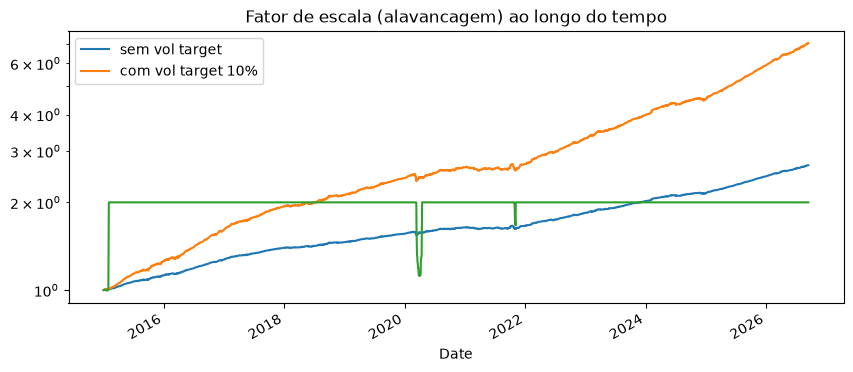

In [40]:
def vol_target_scale(ret, target=0.10, window=21, max_leverage=2.0):
    """Fator diário = alvo / vol realizada (defasado 1 dia), limitado."""
    vol = ret.rolling(window).std(ddof=1) * np.sqrt(252)
    return (target / vol).clip(upper=max_leverage).shift(1).fillna(1.0)

p = P["risk_parity"]
k = vol_target_scale(p)
p_vt = k * p + (1 - k).clip(lower=0) * cdi      # o que sobra (quando k < 1) rende CDI

print("vol antes:", round(metrics.annualized_vol(p), 3), " depois:", round(metrics.annualized_vol(p_vt), 3))
pd.DataFrame({"sem vol target": (1 + p).cumprod(), "com vol target 10%": (1 + p_vt).cumprod()}).plot(logy=True)
k.plot(title="Fator de escala (alavancagem) ao longo do tempo");

In [41]:
import statsmodels.api as sm

def regressao_fatores(ret, cdi, F):
    y = (ret - cdi).dropna()
    X = sm.add_constant(F.loc[y.index].dropna())
    y = y.loc[X.index]
    m = sm.OLS(y, X).fit()
    return pd.Series({"alpha_anual": m.params["const"] * 252, "t_alpha": m.tvalues["const"],
                      **{f"beta_{c}": m.params[c] for c in F.columns}, "R2": m.rsquared})

pd.DataFrame({c: regressao_fatores(R[c], cdi, F) for c in R.columns}).T.round(3)

,alpha_anual,t_alpha,beta_MKT,beta_SMB,beta_HML,beta_WML,R2
momentum,-0.013,-0.277,0.942,0.044,0.120,0.347,0.657
reversao,-0.311,-3.071,0.224,0.061,-0.092,0.310,0.036
pares,-0.057,-2.191,-0.076,0.005,0.017,0.038,0.042
carry,-0.001,-0.477,0.002,-0.001,-0.001,-0.000,0.003


In [42]:
def alocacao_rolante(R, cdi, metodo, anos_treino=3):
    anos = sorted(set(R.index.year))
    out = []
    for i in range(anos_treino, len(anos)):
        treino = R[R.index.year.isin(anos[i - anos_treino:i])]
        teste  = R[R.index.year == anos[i]]
        w = metodo(treino) if metodo is not portfolio.max_sharpe else metodo(treino, cdi.reindex(treino.index), w_max=0.4)
        out.append(portfolio.combine(teste, w))
    return pd.concat(out)

P_rol = pd.DataFrame({
    "pesos_iguais": alocacao_rolante(R, cdi, portfolio.equal_weight),
    "risk_parity":  alocacao_rolante(R, cdi, portfolio.risk_parity),
    "max_sharpe":   alocacao_rolante(R, cdi, portfolio.max_sharpe),
})
pd.DataFrame({c: metrics.summary(P_rol[c], cdi) for c in P_rol.columns}).T.round(3)

,ret_anual,vol_anual,sharpe,max_dd
pesos_iguais,0.018,0.112,-0.572,-0.267
risk_parity,0.078,0.017,-0.735,-0.024
max_sharpe,0.095,0.114,0.078,-0.249


In [44]:
pd.DataFrame({"portfolio": p_vt, "cdi": cdi}).to_parquet( DATA / "processed" /"portfolio_final.parquet")